# IMPORTANT - this is not part of the package for the assignment - it was just created to split the annotated data from participant HC



## Split annotated Sensor Logger recordings into `RawNNN_Terrain.zip`

Purpose: recover the two long annotated recordings and convert each annotated terrain interval into the same package structure as `Raw001_Smooth.zip`.

### Important finding about the annotation timestamps

For these iPhone exports, `Annotation.csv["seconds_elapsed"]` is **not in the same clock domain** as the sensor CSVs and is therefore unusable directly. The **differences between `Annotation.csv["time"]` values are consistent**, so this notebook:

1. reconstructs the relative marker timeline from differences in `Annotation.csv["time"]`;
2. estimates the one missing offset between the annotation timeline and the sensor timeline;
3. plots an alignment diagnostic;
4. **refuses to write any ZIP files until you explicitly confirm the alignment**.

The alignment estimator uses the collection protocol itself: after pressing `bumpy starts` / `smooth starts`, the phone is handled and put back into the pocket, which produces a strong short gyroscope transient. The code searches for the constant offset that aligns the annotation markers with these repeated handling transients.

For the two files inspected beforehand, the estimated offsets were approximately:

- `09-02-09`: **3.50 s**
- `10-44-41`: **4.20 s**

The notebook recomputes them locally rather than blindly trusting these values.

A small guard interval is also removed at each boundary to avoid phone-handling / terrain-transition samples entering the later ML pipeline.


In [4]:

from pathlib import Path

SOURCE_DIR = Path("data/downloads/road-checker-data")
OUTPUT_DIR = Path("data/downloads")

SOURCE_FILES = [
    "pt01-annotations-19min-2026-09-19_09-02-09.zip",
    "pt01-annotations-19min-2026-09-19_10-44-41.zip",
]

FIRST_RAW_INDEX = 31

OFFSET_SEARCH_MIN_S = 0.0
OFFSET_SEARCH_MAX_S = 10.0
OFFSET_SEARCH_STEP_S = 0.05

# Marker -> phone handling/pocket -> start riding.
START_GUARD_S = 3.0
END_GUARD_S = 1.0

# Optional overrides after visual inspection, e.g.
# MANUAL_OFFSETS = {
#     "pt01-annotations-19min-2026-09-19_09-02-09.zip": 3.50,
# }
MANUAL_OFFSETS = {}

# Safety switch:
# keep False on the first run, inspect plots + manifest,
# then change to True and rerun the write/validation cells.
CONFIRM_ALIGNMENT_AND_WRITE = True

OVERWRITE_EXISTING_RAW_ZIPS = False


In [5]:

import io
import zipfile
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


REQUIRED_FILES = {
    "Accelerometer.csv",
    "Gravity.csv",
    "Gyroscope.csv",
    "Metadata.csv",
    "Annotation.csv",
}


def read_csv_from_zip(zf, name):
    raw = zf.read(name)
    if not raw.strip():
        return None
    return pd.read_csv(io.BytesIO(raw))


def terrain_from_annotation(text):
    text = str(text).strip().lower()
    if text == "smooth starts":
        return "Smooth"
    if text == "bumpy starts":
        return "Bumpy"
    raise ValueError(f"Unexpected annotation label: {text!r}")


def annotation_relative_timeline(annotation_df):
    if annotation_df is None or annotation_df.empty:
        raise ValueError("Annotation.csv is empty.")

    if "time" not in annotation_df.columns or "text" not in annotation_df.columns:
        raise ValueError("Annotation.csv does not contain the expected 'time' and 'text' columns.")

    out = annotation_df.copy()
    time_ns = out["time"].astype("int64").to_numpy()

    if np.any(np.diff(time_ns) <= 0):
        raise ValueError("Annotation time values are not strictly increasing.")

    out["relative_marker_s"] = (time_ns - time_ns[0]) / 1e9
    out["terrain"] = out["text"].map(terrain_from_annotation)
    return out


def sampling_frequency(df):
    t = df["seconds_elapsed"].to_numpy(float)
    return 1.0 / np.median(np.diff(t))


def load_source(source_path):
    with zipfile.ZipFile(source_path) as zf:
        names = set(zf.namelist())
        missing = REQUIRED_FILES - names
        if missing:
            raise ValueError(f"{source_path.name}: missing files: {sorted(missing)}")

        ann = read_csv_from_zip(zf, "Annotation.csv")
        acc = read_csv_from_zip(zf, "Accelerometer.csv")
        grav = read_csv_from_zip(zf, "Gravity.csv")
        gyro = read_csv_from_zip(zf, "Gyroscope.csv")
        metadata = read_csv_from_zip(zf, "Metadata.csv")

    ann = annotation_relative_timeline(ann)

    return {
        "path": source_path,
        "annotation": ann,
        "accelerometer": acc,
        "gravity": grav,
        "gyroscope": gyro,
        "metadata": metadata,
    }


def estimate_annotation_offset(
    source,
    min_offset_s=0.0,
    max_offset_s=10.0,
    step_s=0.05,
    pre_window_s=2.0,
    post_window_s=2.0,
):
    # Protocol-based alignment heuristic:
    # align markers with repeated phone-handling/pocket-insertion gyroscope spikes.

    gyro = source["gyroscope"]
    ann = source["annotation"]

    t = gyro["seconds_elapsed"].to_numpy(float)
    gyro_mag = np.linalg.norm(
        gyro[["x", "y", "z"]].to_numpy(float),
        axis=1,
    )
    rel_markers = ann["relative_marker_s"].to_numpy(float)

    candidates = np.arange(
        min_offset_s,
        max_offset_s + step_s / 2,
        step_s,
    )

    scores = []

    for offset in candidates:
        marker_scores = []

        for rel_s in rel_markers:
            marker_s = rel_s + offset

            before = (t >= marker_s - pre_window_s) & (t < marker_s)
            after = (t >= marker_s) & (t < marker_s + post_window_s)

            if before.sum() < 10 or after.sum() < 10:
                continue

            marker_score = (
                np.percentile(gyro_mag[after], 95)
                - np.median(gyro_mag[before])
            )
            marker_scores.append(marker_score)

        scores.append(
            np.mean(marker_scores) if marker_scores else np.nan
        )

    scores = np.asarray(scores, dtype=float)

    if np.all(np.isnan(scores)):
        raise ValueError(
            f"Could not estimate alignment for {source['path'].name}"
        )

    best_idx = int(np.nanargmax(scores))
    best_offset = float(candidates[best_idx])
    best_score = float(scores[best_idx])
    median_score = float(np.nanmedian(scores))
    confidence_ratio = best_score / max(abs(median_score), 1e-9)

    return {
        "best_offset_s": best_offset,
        "best_score": best_score,
        "median_score": median_score,
        "confidence_ratio": confidence_ratio,
        "candidates": candidates,
        "scores": scores,
    }



## 1. Audit the source ZIPs and estimate the annotation offsets

The expected result for these recordings is that `Annotation.csv["seconds_elapsed"]` is clearly invalid (large negative values), while relative differences in `Annotation.csv["time"]` produce a sensible marker sequence within the ~19-minute sensor recording.


In [6]:

sources = {}
alignment = {}
audit_rows = []

for filename in SOURCE_FILES:
    source_path = SOURCE_DIR / filename

    if not source_path.exists():
        raise FileNotFoundError(
            f"Could not find {source_path}\n"
            "Check DOWNLOADS_DIR and SOURCE_FILES."
        )

    source = load_source(source_path)
    sources[filename] = source

    acc = source["accelerometer"]
    grav = source["gravity"]
    gyro = source["gyroscope"]
    ann = source["annotation"]

    sensor_start = float(acc["seconds_elapsed"].iloc[0])
    sensor_end = float(acc["seconds_elapsed"].iloc[-1])

    with zipfile.ZipFile(source_path) as zf:
        raw_ann = read_csv_from_zip(zf, "Annotation.csv")

    annotation_seconds_valid = bool(
        raw_ann["seconds_elapsed"].between(
            sensor_start - 1.0,
            sensor_end + 1.0,
        ).all()
    )

    result = estimate_annotation_offset(
        source,
        min_offset_s=OFFSET_SEARCH_MIN_S,
        max_offset_s=OFFSET_SEARCH_MAX_S,
        step_s=OFFSET_SEARCH_STEP_S,
    )

    if filename in MANUAL_OFFSETS:
        result["used_offset_s"] = float(MANUAL_OFFSETS[filename])
        result["offset_source"] = "manual"
    else:
        result["used_offset_s"] = result["best_offset_s"]
        result["offset_source"] = "automatic"

    alignment[filename] = result

    last_marker = (
        float(ann["relative_marker_s"].iloc[-1])
        + result["used_offset_s"]
    )

    audit_rows.append({
        "source": filename,
        "sensor_duration_s": sensor_end,
        "accelerometer_hz": sampling_frequency(acc),
        "gravity_hz": sampling_frequency(grav),
        "gyroscope_hz": sampling_frequency(gyro),
        "annotation_seconds_elapsed_valid": annotation_seconds_valid,
        "n_markers": len(ann),
        "last_aligned_marker_s": last_marker,
        "estimated_offset_s": result["best_offset_s"],
        "used_offset_s": result["used_offset_s"],
        "alignment_confidence_ratio": result["confidence_ratio"],
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df.round(3))

for filename, source in sources.items():
    print(f"\n--- {filename} ---")
    print(
        source["annotation"][[
            "relative_marker_s",
            "text",
            "terrain",
        ]].to_string(index=False)
    )

    valid = audit_df.loc[
        audit_df["source"] == filename,
        "annotation_seconds_elapsed_valid",
    ].iloc[0]

    if valid:
        print("Annotation seconds_elapsed appears usable.")
    else:
        print(
            "WARNING: Annotation seconds_elapsed is NOT in the "
            "sensor clock domain. It will be ignored."
        )


,source,sensor_duration_s,accelerometer_hz,gravity_hz,gyroscope_hz,annotation_seconds_elapsed_valid,n_markers,last_aligned_marker_s,estimated_offset_s,used_offset_s,alignment_confidence_ratio
0,pt01-annotations-19min-2026-09-19_09-02-09.zip,1194.596,99.611,99.611,99.611,False,7,1066.329,3.5,3.5,3.802
1,pt01-annotations-19min-2026-09-19_10-44-41.zip,1178.525,99.611,99.611,99.611,False,4,990.071,4.2,4.2,3.635



--- pt01-annotations-19min-2026-09-19_09-02-09.zip ---
 relative_marker_s          text terrain
             0.000  bumpy starts   Bumpy
           114.806 smooth starts  Smooth
           171.434  bumpy starts   Bumpy
           231.755 smooth starts  Smooth
           820.826  bumpy starts   Bumpy
           867.777 smooth starts  Smooth
          1062.829  bumpy starts   Bumpy

--- pt01-annotations-19min-2026-09-19_10-44-41.zip ---
 relative_marker_s          text terrain
             0.000 smooth starts  Smooth
           104.283  bumpy starts   Bumpy
           259.646 smooth starts  Smooth
           985.871  bumpy starts   Bumpy



## 2. Visual alignment check — do not skip this

For each source:

- top: alignment score versus candidate offset;
- bottom: gyroscope magnitude with reconstructed terrain markers.

The automatic offset should sit at a clear score peak. The marker lines should coincide with repeated handling / transition events from the collection protocol.

If they do not, add corrected values to `MANUAL_OFFSETS`, then rerun.


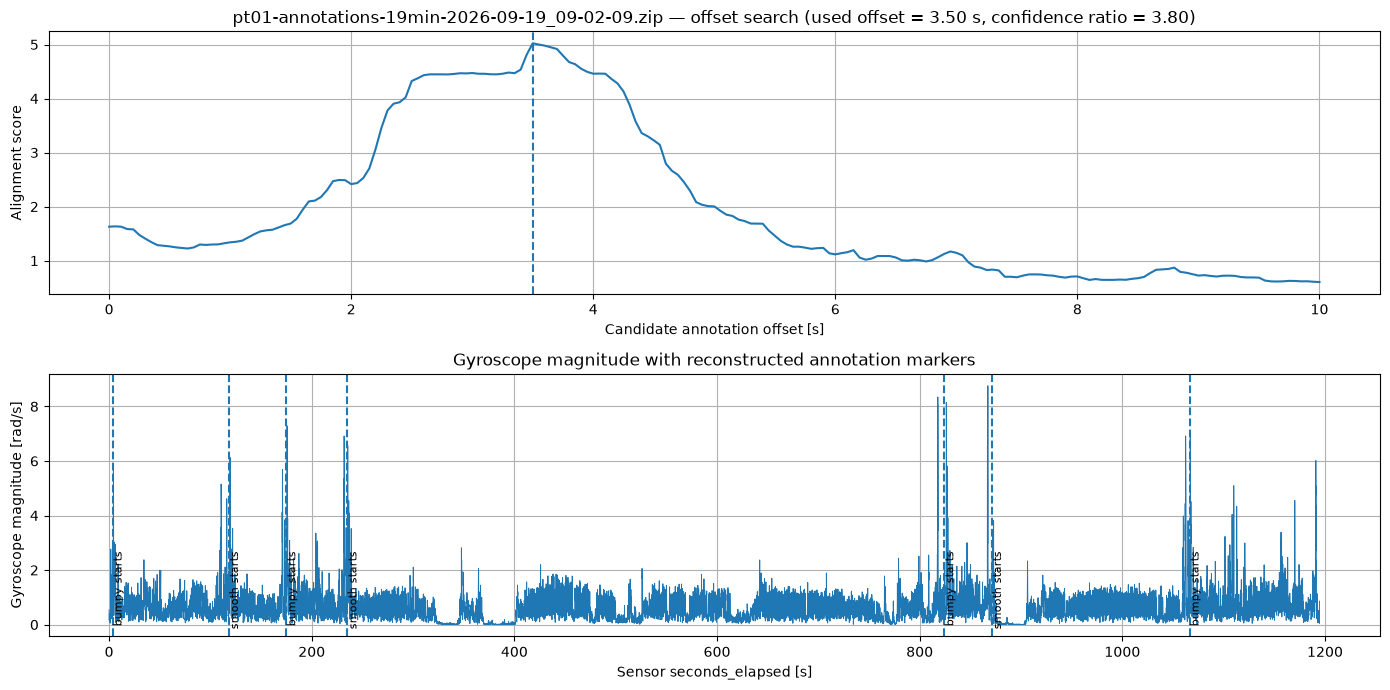

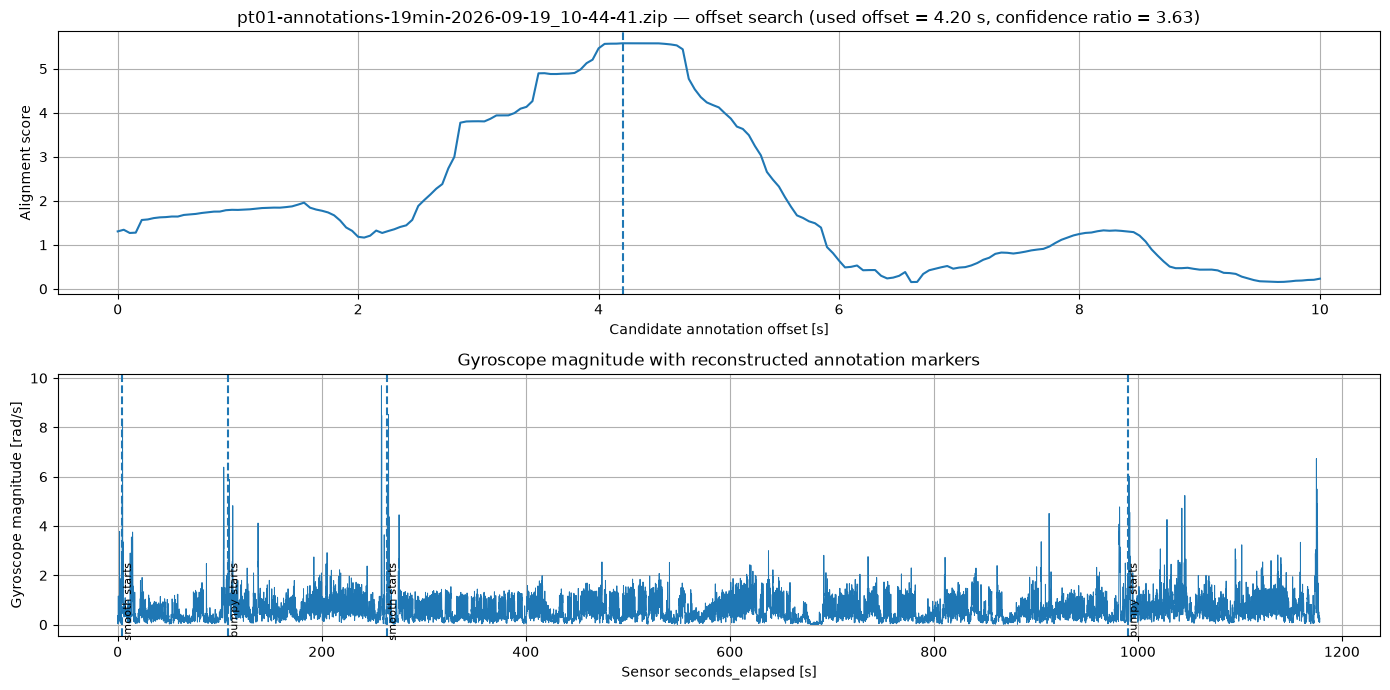

In [7]:

for filename, source in sources.items():
    result = alignment[filename]

    gyro = source["gyroscope"]
    ann = source["annotation"]

    t = gyro["seconds_elapsed"].to_numpy(float)
    gyro_mag = np.linalg.norm(
        gyro[["x", "y", "z"]].to_numpy(float),
        axis=1,
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    axes[0].plot(result["candidates"], result["scores"])
    axes[0].axvline(result["used_offset_s"], linestyle="--")
    axes[0].set_title(
        f"{filename} — offset search "
        f"(used offset = {result['used_offset_s']:.2f} s, "
        f"confidence ratio = {result['confidence_ratio']:.2f})"
    )
    axes[0].set_xlabel("Candidate annotation offset [s]")
    axes[0].set_ylabel("Alignment score")
    axes[0].grid(True)

    stride = 10
    axes[1].plot(
        t[::stride],
        gyro_mag[::stride],
        linewidth=0.7,
    )

    y_top = np.percentile(gyro_mag, 99)

    for _, row in ann.iterrows():
        marker_s = (
            row["relative_marker_s"]
            + result["used_offset_s"]
        )

        axes[1].axvline(marker_s, linestyle="--")
        axes[1].text(
            marker_s,
            y_top,
            row["text"],
            rotation=90,
            va="top",
            fontsize=8,
        )

    axes[1].set_title(
        "Gyroscope magnitude with reconstructed annotation markers"
    )
    axes[1].set_xlabel("Sensor seconds_elapsed [s]")
    axes[1].set_ylabel("Gyroscope magnitude [rad/s]")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()



## 3. Build the split manifest

No ZIPs are written yet.

Default conservative boundary handling:

- begin each terrain package **3 s after** the aligned marker;
- end it **1 s before** the next marker.

This intentionally sacrifices a few seconds to avoid mislabeled phone-handling / terrain-transition samples.


In [8]:

manifest_rows = []
raw_index = FIRST_RAW_INDEX

for filename in SOURCE_FILES:
    source = sources[filename]
    ann = source["annotation"]
    offset_s = alignment[filename]["used_offset_s"]

    sensor_end_s = float(
        source["accelerometer"]["seconds_elapsed"].iloc[-1]
    )

    for i, row in ann.iterrows():
        marker_s = float(
            row["relative_marker_s"] + offset_s
        )

        if i + 1 < len(ann):
            next_marker_s = float(
                ann["relative_marker_s"].iloc[i + 1]
                + offset_s
            )
        else:
            next_marker_s = sensor_end_s

        start_s = marker_s + START_GUARD_S
        end_s = next_marker_s - END_GUARD_S

        if end_s <= start_s:
            raise ValueError(
                f"{filename}: invalid segment {i}: "
                f"{start_s:.3f} -> {end_s:.3f}"
            )

        terrain = row["terrain"]

        manifest_rows.append({
            "raw_index": raw_index,
            "output_name": f"Raw{raw_index:03d}_{terrain}.zip",
            "source": filename,
            "terrain": terrain,
            "annotation_text": row["text"],
            "relative_marker_s": row["relative_marker_s"],
            "aligned_marker_s": marker_s,
            "segment_start_s": start_s,
            "segment_end_s": end_s,
            "duration_s": end_s - start_s,
        })

        raw_index += 1

manifest_df = pd.DataFrame(manifest_rows)

if manifest_df["output_name"].duplicated().any():
    raise ValueError("Duplicate output names in manifest.")

if (manifest_df["duration_s"] <= 10).any():
    raise ValueError(
        "At least one output segment is <= 10 s. "
        "Review marker alignment."
    )

expected_count = sum(
    len(sources[f]["annotation"])
    for f in SOURCE_FILES
)
assert len(manifest_df) == expected_count

display(
    manifest_df[[
        "output_name",
        "source",
        "terrain",
        "aligned_marker_s",
        "segment_start_s",
        "segment_end_s",
        "duration_s",
    ]].round(3)
)

print(
    f"\nPlanned output: {len(manifest_df)} ZIP files, "
    f"Raw{FIRST_RAW_INDEX:03d} through "
    f"Raw{manifest_df['raw_index'].max():03d}."
)


,output_name,source,terrain,aligned_marker_s,segment_start_s,segment_end_s,duration_s
0,Raw031_Bumpy.zip,pt01-annotations-19min-2026-09-19_09-02-09.zip,Bumpy,3.500,6.500,117.306,110.806
1,Raw032_Smooth.zip,pt01-annotations-19min-2026-09-19_09-02-09.zip,Smooth,118.306,121.306,173.934,52.628
2,Raw033_Bumpy.zip,pt01-annotations-19min-2026-09-19_09-02-09.zip,Bumpy,174.934,177.934,234.255,56.321
3,Raw034_Smooth.zip,pt01-annotations-19min-2026-09-19_09-02-09.zip,Smooth,235.255,238.255,823.326,585.071
4,Raw035_Bumpy.zip,pt01-annotations-19min-2026-09-19_09-02-09.zip,Bumpy,824.326,827.326,870.277,42.951
5,Raw036_Smooth.zip,pt01-annotations-19min-2026-09-19_09-02-09.zip,Smooth,871.277,874.277,1065.329,191.052
6,Raw037_Bumpy.zip,pt01-annotations-19min-2026-09-19_09-02-09.zip,Bumpy,1066.329,1069.329,1193.596,124.267
7,Raw038_Smooth.zip,pt01-annotations-19min-2026-09-19_10-44-41.zip,Smooth,4.200,7.200,107.483,100.283
8,Raw039_Bumpy.zip,pt01-annotations-19min-2026-09-19_10-44-41.zip,Bumpy,108.483,111.483,262.846,151.363
9,Raw040_Smooth.zip,pt01-annotations-19min-2026-09-19_10-44-41.zip,Smooth,263.846,266.846,989.071,722.225



Planned output: 11 ZIP files, Raw031 through Raw041.



## 4. Write the new `RawNNN_Terrain.zip` packages

**Safety gate:** this cell stops unless `CONFIRM_ALIGNMENT_AND_WRITE = True`.

For each output package:

- every sensor CSV is sliced to the same terrain interval;
- absolute `time` is preserved;
- `seconds_elapsed` is rebased to the new package start;
- `Metadata.csv` gets a new recording epoch/start time;
- `Annotation.csv` is made empty, matching the existing single-terrain packages.


In [9]:

def write_segment_zip(source, manifest_row, output_dir):
    source_path = source["path"]
    output_path = output_dir / manifest_row["output_name"]

    if output_path.exists() and not OVERWRITE_EXISTING_RAW_ZIPS:
        raise FileExistsError(
            f"{output_path} already exists. "
            "Set OVERWRITE_EXISTING_RAW_ZIPS=True only if intentional."
        )

    start_s = float(manifest_row["segment_start_s"])
    end_s = float(manifest_row["segment_end_s"])

    with zipfile.ZipFile(source_path) as src:
        names = src.namelist()
        metadata = read_csv_from_zip(
            src,
            "Metadata.csv",
        ).copy()

        original_epoch_ms = int(
            metadata.loc[0, "recording epoch time"]
        )

        new_epoch_s = (
            original_epoch_ms / 1000.0
            + start_s
        )
        new_epoch_ms = int(round(new_epoch_s * 1000))

        metadata.loc[0, "recording epoch time"] = new_epoch_ms

        timezone_name = str(
            metadata.loc[0, "recording timezone"]
        )

        try:
            local_start = datetime.fromtimestamp(
                new_epoch_s,
                tz=ZoneInfo(timezone_name),
            )
            metadata.loc[0, "recording time"] = (
                local_start.strftime("%Y-%m-%d_%H-%M-%S")
            )
        except Exception:
            pass

        with zipfile.ZipFile(
            output_path,
            mode="w",
            compression=zipfile.ZIP_DEFLATED,
        ) as out:

            for name in names:

                if name == "Metadata.csv":
                    out.writestr(
                        name,
                        metadata.to_csv(index=False),
                    )
                    continue

                if name == "Annotation.csv":
                    out.writestr(name, b"")
                    continue

                if not name.endswith(".csv"):
                    out.writestr(name, src.read(name))
                    continue

                sensor_df = read_csv_from_zip(src, name)

                if sensor_df is None:
                    out.writestr(name, b"")
                    continue

                if "seconds_elapsed" not in sensor_df.columns:
                    out.writestr(
                        name,
                        sensor_df.to_csv(index=False),
                    )
                    continue

                cut = sensor_df[
                    (sensor_df["seconds_elapsed"] >= start_s)
                    & (sensor_df["seconds_elapsed"] < end_s)
                ].copy()

                if cut.empty:
                    raise ValueError(
                        f"{manifest_row['output_name']}: "
                        f"no samples selected from {name}"
                    )

                if "time" in cut.columns:
                    cut["seconds_elapsed"] = (
                        cut["time"].astype("int64") / 1e9
                        - new_epoch_s
                    )
                else:
                    cut["seconds_elapsed"] -= start_s

                out.writestr(
                    name,
                    cut.to_csv(index=False),
                )

    return output_path


if not CONFIRM_ALIGNMENT_AND_WRITE:
    raise RuntimeError(
        "Safety stop: no files were written.\n\n"
        "Inspect the alignment plots and manifest above. "
        "If they look correct, change "
        "CONFIRM_ALIGNMENT_AND_WRITE = True "
        "and rerun this cell."
    )


created_files = []

for filename in SOURCE_FILES:
    source = sources[filename]

    source_rows = manifest_df[
        manifest_df["source"] == filename
    ]

    for _, manifest_row in source_rows.iterrows():
        created_files.append(
            write_segment_zip(
                source,
                manifest_row,
                OUTPUT_DIR,
            )
        )

manifest_path = OUTPUT_DIR / (
    f"annotated_split_manifest_"
    f"Raw{FIRST_RAW_INDEX:03d}-"
    f"Raw{manifest_df['raw_index'].max():03d}.csv"
)

manifest_df.to_csv(manifest_path, index=False)

print(f"Created {len(created_files)} ZIP files.")
print(f"Manifest: {manifest_path}")

for path in created_files:
    print(path)


Created 11 ZIP files.
Manifest: data/downloads/annotated_split_manifest_Raw031-Raw041.csv
data/downloads/Raw031_Bumpy.zip
data/downloads/Raw032_Smooth.zip
data/downloads/Raw033_Bumpy.zip
data/downloads/Raw034_Smooth.zip
data/downloads/Raw035_Bumpy.zip
data/downloads/Raw036_Smooth.zip
data/downloads/Raw037_Bumpy.zip
data/downloads/Raw038_Smooth.zip
data/downloads/Raw039_Bumpy.zip
data/downloads/Raw040_Smooth.zip
data/downloads/Raw041_Bumpy.zip



## 5. Validate every generated ZIP

This reopens every generated package and checks:

- required files exist;
- calibrated sensors contain data;
- timestamps are monotonic;
- rebased `seconds_elapsed` starts close to zero;
- sampling frequency remains near 100 Hz;
- `Annotation.csv` is empty.

Do not upload generated files if any row fails.


In [10]:

def validate_generated_zip(zip_path):
    result = {
        "zip": zip_path.name,
        "ok": True,
        "problem": "",
    }

    try:
        with zipfile.ZipFile(zip_path) as zf:
            names = set(zf.namelist())

            missing = REQUIRED_FILES - names
            if missing:
                raise ValueError(
                    f"missing files: {sorted(missing)}"
                )

            if len(zf.read("Annotation.csv")) != 0:
                raise ValueError(
                    "Annotation.csv should be empty."
                )

            frequencies = []
            starts = []
            durations = []

            for sensor_file in [
                "Accelerometer.csv",
                "Gravity.csv",
                "Gyroscope.csv",
            ]:
                sensor_df = read_csv_from_zip(
                    zf,
                    sensor_file,
                )

                if sensor_df is None or len(sensor_df) < 3:
                    raise ValueError(
                        f"{sensor_file} contains too few samples"
                    )

                elapsed = sensor_df[
                    "seconds_elapsed"
                ].to_numpy(float)

                if np.any(np.diff(elapsed) <= 0):
                    raise ValueError(
                        f"{sensor_file}: non-monotonic "
                        "seconds_elapsed"
                    )

                frequencies.append(
                    1.0 / np.median(np.diff(elapsed))
                )
                starts.append(float(elapsed[0]))
                durations.append(float(elapsed[-1]))

            result["fs_min_hz"] = min(frequencies)
            result["fs_max_hz"] = max(frequencies)
            result["largest_initial_delay_s"] = max(starts)
            result["shortest_sensor_duration_s"] = min(durations)

            if not (
                95.0 <= result["fs_min_hz"] <= 105.0
                and 95.0 <= result["fs_max_hz"] <= 105.0
            ):
                raise ValueError(
                    "sampling frequency outside expected ~100 Hz range"
                )

            if result["largest_initial_delay_s"] > 0.1:
                raise ValueError(
                    "rebased recording does not start close to zero"
                )

    except Exception as exc:
        result["ok"] = False
        result["problem"] = str(exc)

    return result


if CONFIRM_ALIGNMENT_AND_WRITE:
    validation_df = pd.DataFrame([
        validate_generated_zip(path)
        for path in created_files
    ])

    display(validation_df.round(4))

    if not validation_df["ok"].all():
        raise RuntimeError(
            "At least one generated package failed validation. "
            "Do NOT upload the files yet."
        )

    print(
        "\nAll generated Raw packages passed validation. "
        "They are ready for the Drive folder and main notebook."
    )
else:
    print(
        "Validation will run after "
        "CONFIRM_ALIGNMENT_AND_WRITE=True "
        "and the ZIPs are generated."
    )


,zip,ok,problem,fs_min_hz,fs_max_hz,largest_initial_delay_s,shortest_sensor_duration_s
0,Raw031_Bumpy.zip,True,,99.6106,99.6106,0.0090,110.8024
1,Raw032_Smooth.zip,True,,99.6106,99.6106,0.0026,52.6191
2,Raw033_Bumpy.zip,True,,99.6106,99.6106,0.0074,56.3169
3,Raw034_Smooth.zip,True,,99.6106,99.6106,0.0021,585.0696
4,Raw035_Bumpy.zip,True,,99.6106,99.6106,0.0060,42.9447
5,Raw036_Smooth.zip,True,,99.6106,99.6106,0.0100,191.0426
6,Raw037_Bumpy.zip,True,,99.6106,99.6106,0.0093,124.2632
7,Raw038_Smooth.zip,True,,99.6106,99.6106,0.0001,100.2816
8,Raw039_Bumpy.zip,True,,99.6106,99.6106,0.0036,151.3552
9,Raw040_Smooth.zip,True,,99.6106,99.6106,0.0079,722.2197



All generated Raw packages passed validation. They are ready for the Drive folder and main notebook.



## 6. Important: preserve the original parent session for train/test grouping

`Raw031`–`Raw037` come from one continuous parent recording, and `Raw038`–`Raw041` come from the other.

After chopping them into terrain ZIPs, **do not treat every new ZIP as an independent train/test group**. Otherwise, segments from the same ride/session could appear on both sides of the split and make test performance artificially optimistic.

The manifest therefore preserves the original `source` session. Use that parent session as the grouping key for these generated recordings when creating train/test splits.


In [11]:

if CONFIRM_ALIGNMENT_AND_WRITE:
    split_group_map = manifest_df[[
        "raw_index",
        "output_name",
        "source",
        "terrain",
    ]].copy()

    split_group_map["recording_id"] = split_group_map[
        "raw_index"
    ].map(lambda n: f"Raw{int(n):03d}")

    split_group_map["split_group"] = split_group_map["source"]

    split_group_map = split_group_map[[
        "recording_id",
        "terrain",
        "split_group",
        "output_name",
    ]]

    group_map_path = OUTPUT_DIR / (
        f"annotated_split_group_map_"
        f"Raw{FIRST_RAW_INDEX:03d}-"
        f"Raw{manifest_df['raw_index'].max():03d}.csv"
    )

    split_group_map.to_csv(group_map_path, index=False)

    display(split_group_map)
    print(f"Saved grouping map: {group_map_path}")
else:
    print(
        "The train/test grouping map will be created after "
        "the ZIP files are written."
    )


,recording_id,terrain,split_group,output_name
0,Raw031,Bumpy,pt01-annotations-19min-2026-09-19_09-02-09.zip,Raw031_Bumpy.zip
1,Raw032,Smooth,pt01-annotations-19min-2026-09-19_09-02-09.zip,Raw032_Smooth.zip
2,Raw033,Bumpy,pt01-annotations-19min-2026-09-19_09-02-09.zip,Raw033_Bumpy.zip
3,Raw034,Smooth,pt01-annotations-19min-2026-09-19_09-02-09.zip,Raw034_Smooth.zip
4,Raw035,Bumpy,pt01-annotations-19min-2026-09-19_09-02-09.zip,Raw035_Bumpy.zip
5,Raw036,Smooth,pt01-annotations-19min-2026-09-19_09-02-09.zip,Raw036_Smooth.zip
6,Raw037,Bumpy,pt01-annotations-19min-2026-09-19_09-02-09.zip,Raw037_Bumpy.zip
7,Raw038,Smooth,pt01-annotations-19min-2026-09-19_10-44-41.zip,Raw038_Smooth.zip
8,Raw039,Bumpy,pt01-annotations-19min-2026-09-19_10-44-41.zip,Raw039_Bumpy.zip
9,Raw040,Smooth,pt01-annotations-19min-2026-09-19_10-44-41.zip,Raw040_Smooth.zip


Saved grouping map: data/downloads/annotated_split_group_map_Raw031-Raw041.csv
